<a href="https://colab.research.google.com/github/KesariBharathReddy/IAIP/blob/main/SALES_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('sales_data.csv', encoding='latin1')

In [2]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [4]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [5]:
df['Sale_Date']=pd.to_datetime(df['Sale_Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

In [7]:
df['Year']=df['Sale_Date'].dt.year
df['Month']=df['Sale_Date'].dt.month

In [8]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Year,Month
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2023,2
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,2023,4
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,2023,9
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,2023,8
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,2023,3


In [9]:
monthly_sales=df.groupby('Month')['Sales_Amount'].sum()
print(monthly_sales)

Month
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: Sales_Amount, dtype: float64


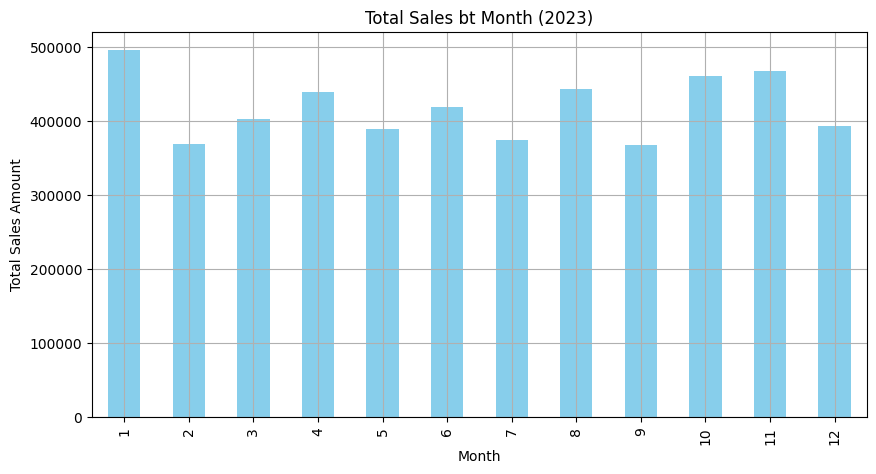

In [10]:
monthly_sales.plot(kind='bar', figsize=(10,5), color="skyblue")
plt.title('Total Sales bt Month (2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.grid(True)
plt.show()

In [11]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum()
print(category_sales)

Product_Category
Clothing       1313474.36
Electronics    1243499.64
Food           1201773.54
Furniture      1260517.69
Name: Sales_Amount, dtype: float64


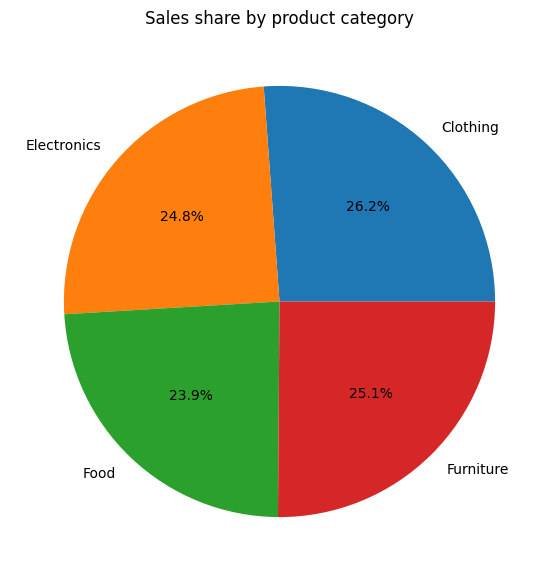

In [12]:
category_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Sales share by product category')
plt.ylabel('')
plt.show()

Region
East     1259792.93
North    1369612.51
South    1154250.86
West     1235608.93
Name: Sales_Amount, dtype: float64


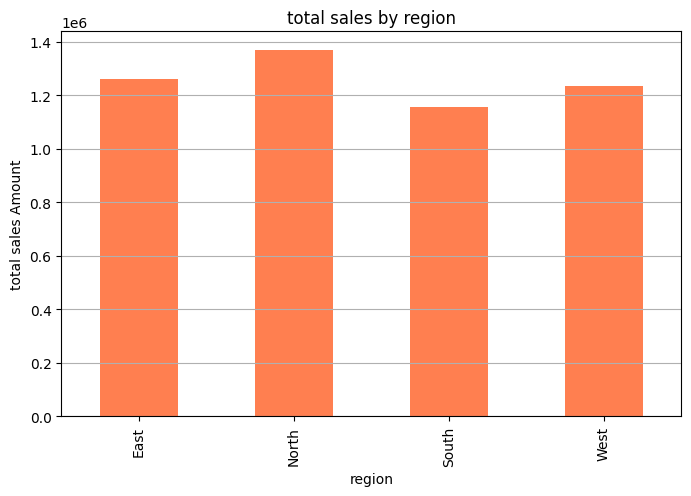

In [13]:
region_sales = df.groupby('Region')['Sales_Amount'].sum()
print(region_sales)

region_sales.plot(kind='bar', figsize=(8,5),color='coral')
plt.title('total sales by region')
plt.xlabel('region')
plt.ylabel('total sales Amount')
plt.grid(axis='y')
plt.show()

In [14]:
heatmap_data = df.pivot_table(index='Month', columns='Product_Category', values='Sales_Amount', aggfunc='sum')
print(heatmap_data)

Product_Category   Clothing  Electronics       Food  Furniture
Month                                                         
1                 132877.78    105483.44   94765.52  162293.63
2                  90815.67     89530.85   91206.13   97366.71
3                 128934.01     97875.50   87969.27   87859.99
4                  99974.35    127514.53  126410.50   85093.23
5                  97836.73     72189.35   97178.92  121873.76
6                  89701.64    123107.56   58406.76  147242.38
7                  91222.38    112643.73   79491.25   90885.52
8                 148120.35     92009.25  120341.76   82699.92
9                  85187.83    104785.10   91081.50   86783.17
10                117824.74    132904.61  111419.33   98230.10
11                120309.55     79415.94  164349.34  103408.07
12                110669.33    106039.78   79153.26   96781.21


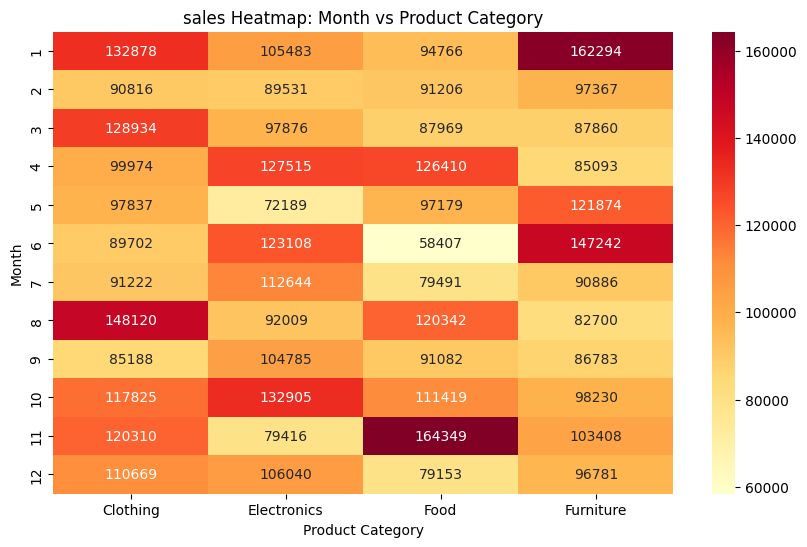

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('sales Heatmap: Month vs Product Category')
plt.xlabel('Product Category')
plt.ylabel('Month')
plt.show()

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Sales_Amount, dtype: float64


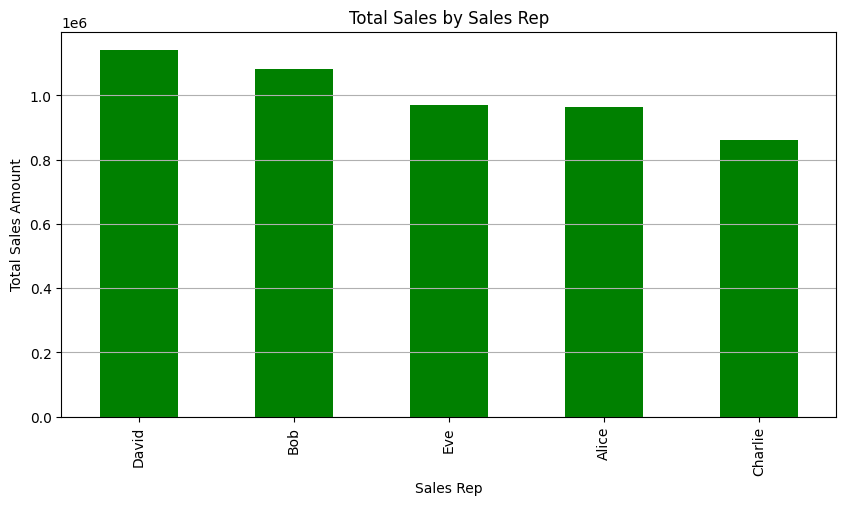

In [16]:
rep_sales = df.groupby('Sales_Rep')['Sales_Amount'].sum().sort_values(ascending=False)
print(rep_sales)

rep_sales.plot(kind='bar', figsize=(10,5), color='green')
plt.title('Total Sales by Sales Rep')
plt.xlabel('Sales Rep')
plt.ylabel('Total Sales Amount')
plt.grid(axis='y')
plt.show()

**Conclusion: Sales Data Analysis**
This analysis examined sales trends, seasonal effects, and product performance using a dataset of 1000 sales records across 4 product categories, 4 regions, 5 sales reps, and 12 months.

**1. Monthly Sales Trends**
Total sales fluctuate throughout the year rather than following one steady trend. January was the strongest month (approx.₹495,420), while September was the weakest (~₹367,837).

**2. Product Category Performance**
Sales are fairly evenly distributed across all four categories: Clothing (26.2%), Furniture (25.1%), Electronics (24.8%), and Food (23.9%). No single category dominates, indicating a balanced product mix.

**3. Regional Performance**
The North region generated the highest total sales (approx.₹1,369,612), while the South region generated the lowest (~₹1,154,250). East and West performed similarly, in between.

**4. Seasonal Effects by Category**
Seasonality is category-specific rather than uniform: Furniture and Clothing peak in January, Food peaks sharply in November, and Electronics performs best in April and October.

**5. Sales Rep Performance**
David was the top-performing sales rep with total sales of approx.₹1,141,737, followed closely by Bob (approx.₹1,080,990). Eve and Alice performed similarly in the middle (~₹970,183 and ~₹965,541), while Charlie had the lowest total sales at ~₹860,811.

**Overall Conclusion**
The Superstore sales data shows a business with a balanced product portfolio and regional distribution, but with distinct seasonal patterns per category and noticeable variation in individual rep performance. These insights could support targeted promotions (e.g., Food in November, Electronics in April/October), performance coaching for lower-performing reps like Charlie, and further investigation into why the South region underperforms.